In [43]:
import geopandas as gpd
import pandas as pd

import mapillary as mly
import json



### netzwerk einlesen

In [2]:
#highways=gpd.read_file("../preprocessing/processed_osm_files/processed_major_highways_germany_250528.geojson.gz")

# use not only the major highways, but all highways for this
cycleways=gpd.read_file("../preprocessing/processed_osm_files/processed_cycleways_germany_250528.geojson.gz")


In [3]:
cycleways

,osm_id,highway,bicycle,cycleway,cycleway_left,cycleway_opposite,cycleway_right,cycleway_both,cycleway_lane,cycleway_track,maxspeed,maxspeed_conditional,maxspeed_backward,maxspeed_forward,maxspeed_type,name,ref,surface,width,geometry
0,92,residential,None,None,None,None,None,None,None,None,30,None,None,None,None,Eigenheimstraße,None,asphalt,None,"LINESTRING (13.73698 51.01663, 13.73752 51.016..."
1,93,residential,None,None,None,None,None,None,None,None,30,None,None,None,None,Eigenheimberg,None,asphalt,None,"LINESTRING (13.73939 51.01669, 13.73967 51.016..."
2,99,tertiary,None,None,None,None,no,None,None,None,None,None,None,None,None,None,None,asphalt,None,"LINESTRING (11.36639 48.17411, 11.36643 48.174..."
3,103,residential,None,None,None,None,None,None,None,None,5,None,None,None,None,Altmockritz,None,None,None,"LINESTRING (13.74127 51.01615, 13.74149 51.016..."
4,104,unclassified,None,None,None,None,None,no,None,None,50,None,None,None,None,Münzmeisterstraße,None,asphalt,None,"LINESTRING (13.74142 51.02366, 13.74139 51.023..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7336294,1390548863,path,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"LINESTRING (11.38298 52.65611, 11.383 52.6558,..."
7336295,1390548864,path,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"LINESTRING (11.38251 52.65568, 11.38266 52.655..."
7336296,1390548865,path,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"LINESTRING (11.38262 52.65609, 11.38266 52.655..."
7336297,1390550366,path,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,grass,None,"LINESTRING (13.87816 52.08202, 13.87811 52.08226)"


In [5]:
filtered_cycleways = cycleways[
    (cycleways["bicycle"].isin(["yes", "designated"])) |
    (cycleways["highway"].isin(["cycleway"])) |
    (cycleways["cycleway"].notnull()) |
    (cycleways["cycleway_left"].notnull()) |
    (cycleways["cycleway_right"].notnull()) |
    (cycleways["cycleway_both"].notnull()) |
    (cycleways["cycleway_lane"].notnull()) |
    (cycleways["cycleway_track"].notnull()) |
    (cycleways["cycleway_opposite"].notnull()) 
]
filtered_cycleways

,osm_id,highway,bicycle,cycleway,cycleway_left,cycleway_opposite,cycleway_right,cycleway_both,cycleway_lane,cycleway_track,maxspeed,maxspeed_conditional,maxspeed_backward,maxspeed_forward,maxspeed_type,name,ref,surface,width,geometry
2,99,tertiary,None,None,None,None,no,None,None,None,None,None,None,None,None,None,None,asphalt,None,"LINESTRING (11.36639 48.17411, 11.36643 48.174..."
4,104,unclassified,None,None,None,None,None,no,None,None,50,None,None,None,None,Münzmeisterstraße,None,asphalt,None,"LINESTRING (13.74142 51.02366, 13.74139 51.023..."
5,105,residential,None,None,None,None,None,no,None,None,30,None,None,None,None,Altpestitz,None,sett,None,"LINESTRING (13.73698 51.01663, 13.73643 51.016..."
6,107,residential,None,None,None,None,None,no,None,None,30,None,None,None,None,Trienter Straße,None,asphalt,None,"LINESTRING (13.73507 51.01914, 13.73505 51.019..."
9,110,residential,None,None,None,None,None,no,None,None,50,None,None,None,sign,Heinrich-Greif-Straße,None,concrete:plates,None,"LINESTRING (13.74296 51.02871, 13.74295 51.028..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7336276,1390543898,tertiary,None,None,None,None,track,None,None,None,70,None,None,None,sign,Kanalstraße,K 12,asphalt,None,"LINESTRING (10.38261 52.15137, 10.38258 52.151..."
7336277,1390543901,tertiary,use_sidepath,None,no,None,separate,None,None,None,100,None,None,None,None,Kanalstraße,K 13,asphalt,None,"LINESTRING (10.35426 52.15589, 10.3531 52.1559..."
7336278,1390547304,residential,yes,None,None,None,None,no,None,None,30,None,None,None,DE:zone30,Bärensteinstraße,None,asphalt,None,"LINESTRING (13.56704 52.54126, 13.56704 52.541..."
7336279,1390547305,residential,yes,None,None,None,None,no,None,None,30,None,None,None,DE:zone30,Bärensteinstraße,None,asphalt,None,"LINESTRING (13.56703 52.54094, 13.56703 52.541..."


In [6]:
filtered_cycleways.highway.value_counts()

highway
path              430541
residential       345813
secondary         233991
track             190037
tertiary          188369
footway           177095
primary           124364
unclassified      104910
cycleway           89138
service            70855
pedestrian         13871
living_street      13013
primary_link        7240
secondary_link      6275
trunk               3914
trunk_link          3212
tertiary_link       3186
steps               2546
motorway            2298
motorway_link       1797
construction        1519
bridleway            389
proposed             133
platform             101
busway                59
elevator              31
road                  16
bus_stop              13
planned               11
corridor               9
crossing               5
no                     3
disused                2
raceway                2
yes                    1
rest_area              1
razed                  1
passing_place          1
Name: count, dtype: int64

In [ ]:
# # mapillary map feature data: != traffic signs
# https://www.mapillary.com/developer/api-documentation/points?locale=de_DE

# mapillary_mapfeaturepoints = gpd.read_parquet("../preprocessing/mapillary_map-feature-points_data_bbb_2025-06-11.parquet")
# mapillary_mapfeaturepoints


# LANE MARKINGS!!!
# https://www.mapillary.com/developer/api-documentation/points?locale=de_DE
# mapillary_mapfeaturepoints_bclane=mapillary_mapfeaturepoints[mapillary_mapfeaturepoints.value=="marking--discrete--symbol--bicycle"]
# mapillary_mapfeaturepoints_bclane

,geometry,first_seen_at,id,last_seen_at,value,tile_x,tile_y
0,POINT (11.27341 53.11882),2021-07-03,118488700476446,2021-07-03,object--traffic-sign--front,8705,5328
1,POINT (11.27681 53.11384),2021-07-03,1283980285353032,2021-07-03,object--street-light,8705,5328
2,POINT (11.27773 53.10978),2021-07-03,398107614960247,2021-07-03,object--traffic-sign--front,8705,5328
3,POINT (11.27341 53.11882),2021-07-03,118488687143114,2021-07-03,object--traffic-sign--front,8705,5328
4,POINT (11.27292 53.11977),2021-07-03,118488703809779,2021-07-03,object--traffic-sign--front,8705,5328
...,...,...,...,...,...,...,...
2894575,POINT (14.73256 51.65574),2024-06-28,1170872657387552,2024-06-28,object--traffic-sign--front,8862,5437
2894576,POINT (14.73306 51.64995),2024-06-28,991198522456798,2024-06-28,object--traffic-sign--front,8862,5437
2894577,POINT (14.73267 51.6557),2024-06-28,1170872647387553,2024-06-28,object--traffic-sign--temporary-front,8862,5437
2894578,POINT (14.73256 51.65574),2024-06-28,1170872660720885,2024-06-28,object--traffic-sign--front,8862,5437


In [ ]:

## TRAFFFIC SIGNS
# https://www.mapillary.com/developer/api-documentation/traffic-signs?locale=

# Unterschiedliche Verkehrszeichen in Deutschland für Radwege

# https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:237
de_237="regulatory--bicycles-only--g1"

# https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:240
de_240="regulatory--shared-path-pedestrians-and-bicycles--g1"

# https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:241-30
de_241_30="regulatory--dual-path-bicycles-and-pedestrians--g1"

# https://trafficsigns.osm-verkehrswende.org/DE?signs=DE:241-31
de_241_31="regulatory--dual-path-pedestrians-and-bicycles--g1"



mapillary_trafficsigns = gpd.read_parquet("../preprocessing/mapillary_map-feature-data_ger_2025-06-07.parquet")


# Schilder in Germany
mapillary_trafficsigns_cw=mapillary_trafficsigns[mapillary_trafficsigns.value.isin([de_237, de_240, de_241_30, de_241_31])]
mapillary_trafficsigns_cw

,geometry,first_seen_at,id,last_seen_at,value
165,POINT (5.90829 51.01523),2016-07-30,301371998064492,2016-07-30,regulatory--bicycles-only--g1
266,POINT (5.90258 51.01893),2016-07-30,854188721831494,2016-07-30,regulatory--shared-path-pedestrians-and-bicycl...
296,POINT (5.90813 51.01569),2016-11-19,4338004276257040,2016-11-19,regulatory--shared-path-pedestrians-and-bicycl...
311,POINT (5.90159 51.01922),2015-02-07,3249656101804613,2015-02-07,regulatory--shared-path-pedestrians-and-bicycl...
556,POINT (5.89001 51.0097),2019-02-16,531235461227628,2019-02-16,regulatory--bicycles-only--g1
...,...,...,...,...,...
5347902,POINT (15.00537 51.15164),2022-08-08,743733120187364,2022-08-08,regulatory--shared-path-pedestrians-and-bicycl...
5347986,POINT (15.0065 51.14989),2020-01-11,276788914172131,2020-01-11,regulatory--dual-path-bicycles-and-pedestrians...
5348009,POINT (15.00592 51.1499),2024-04-19,1105868117290058,2024-04-19,regulatory--shared-path-pedestrians-and-bicycl...
5348028,POINT (15.00663 51.14983),2020-01-11,277843004066722,2022-07-28,regulatory--dual-path-bicycles-and-pedestrians...


In [ ]:
# mapillary_trafficsigns_237_recent = mapillary_trafficsigns_cw[mapillary_trafficsigns_cw["last_seen_at"] > "2024-01-01"]
# mapillary_trafficsigns_237_recent

,geometry,first_seen_at,id,last_seen_at,value
2482,POINT (5.9588 50.80571),2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1
2493,POINT (5.95875 50.80574),2014-11-19,918053748737717,2025-05-09,regulatory--bicycles-only--g1
2522,POINT (5.95895 50.80559),2025-05-09,1356063172207640,2025-05-09,regulatory--bicycles-only--g1
4842,POINT (6.0416 51.78278),2024-07-16,790775723234577,2025-05-10,regulatory--bicycles-only--g1
4846,POINT (6.04144 51.78271),2022-05-08,113625711209311,2024-07-16,regulatory--bicycles-only--g1
...,...,...,...,...,...
5334912,POINT (14.79116 50.89899),2024-04-18,1377650766235670,2024-04-18,regulatory--bicycles-only--g1
5336026,POINT (14.81998 50.89838),2024-04-20,462643972872333,2024-04-20,regulatory--bicycles-only--g1
5338676,POINT (14.93033 51.02413),2016-08-24,189541433016925,2024-04-20,regulatory--bicycles-only--g1
5338746,POINT (14.93045 51.02416),2023-10-24,353297440600343,2024-04-20,regulatory--bicycles-only--g1


In [20]:
from datetime import datetime

def months_between(date1, date2):
    d1 = datetime.strptime(date1, "%Y-%m-%d")
    d2 = datetime.strptime(date2, "%Y-%m-%d")
    return abs((d2.year - d1.year) * 12 + d2.month - d1.month)

mapillary_trafficsigns_cw_1year = mapillary_trafficsigns_cw[
    mapillary_trafficsigns_cw.apply(lambda row: months_between(row['first_seen_at'], row['last_seen_at']) >= 12, axis=1)
]
mapillary_trafficsigns_cw_1year

,geometry,first_seen_at,id,last_seen_at,value
1738,POINT (5.9678 51.80976),2020-05-23,4324714694228518,2025-05-10,regulatory--shared-path-pedestrians-and-bicycl...
1745,POINT (5.96458 51.812),2017-03-24,2988469541382285,2023-03-18,regulatory--shared-path-pedestrians-and-bicycl...
1768,POINT (5.96452 51.81211),2022-11-05,654455459471944,2024-07-16,regulatory--shared-path-pedestrians-and-bicycl...
1914,POINT (5.96422 51.81174),2022-11-05,654455462805277,2025-03-22,regulatory--shared-path-pedestrians-and-bicycl...
2482,POINT (5.9588 50.80571),2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1
...,...,...,...,...,...
5345840,POINT (14.9908 51.1509),2018-09-04,249372320311931,2022-07-28,regulatory--shared-path-pedestrians-and-bicycl...
5345892,POINT (15.00625 51.1497),2020-02-20,1520496191675299,2022-07-28,regulatory--shared-path-pedestrians-and-bicycl...
5347014,POINT (14.99091 51.15028),2021-06-28,1706665812854785,2022-06-22,regulatory--shared-path-pedestrians-and-bicycl...
5347838,POINT (15.00439 51.15082),2019-05-23,739427700031617,2024-01-31,regulatory--shared-path-pedestrians-and-bicycl...


<Axes: >

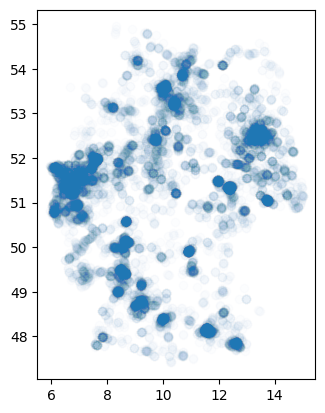

In [24]:
mapillary_trafficsigns_cw_1year.plot(alpha=0.01)

In [25]:
df_buffered = mapillary_trafficsigns_cw_1year.to_crs(25833).copy()
df_buffered["geometry"] = df_buffered.geometry.buffer(50)
df_buffered = df_buffered.to_crs(mapillary_trafficsigns_cw_1year.crs)
df_buffered

,geometry,first_seen_at,id,last_seen_at,value
1738,"POLYGON ((5.96851 51.80981, 5.96852 51.80977, ...",2020-05-23,4324714694228518,2025-05-10,regulatory--shared-path-pedestrians-and-bicycl...
1745,"POLYGON ((5.96529 51.81206, 5.9653 51.81202, 5...",2017-03-24,2988469541382285,2023-03-18,regulatory--shared-path-pedestrians-and-bicycl...
1768,"POLYGON ((5.96524 51.81216, 5.96525 51.81212, ...",2022-11-05,654455459471944,2024-07-16,regulatory--shared-path-pedestrians-and-bicycl...
1914,"POLYGON ((5.96494 51.8118, 5.96494 51.81175, 5...",2022-11-05,654455462805277,2025-03-22,regulatory--shared-path-pedestrians-and-bicycl...
2482,"POLYGON ((5.9595 50.80577, 5.95951 50.80572, 5...",2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1
...,...,...,...,...,...
5345840,"POLYGON ((14.99151 51.1509, 14.99151 51.15086,...",2018-09-04,249372320311931,2022-07-28,regulatory--shared-path-pedestrians-and-bicycl...
5345892,"POLYGON ((15.00697 51.1497, 15.00696 51.14965,...",2020-02-20,1520496191675299,2022-07-28,regulatory--shared-path-pedestrians-and-bicycl...
5347014,"POLYGON ((14.99163 51.15028, 14.99163 51.15024...",2021-06-28,1706665812854785,2022-06-22,regulatory--shared-path-pedestrians-and-bicycl...
5347838,"POLYGON ((15.0051 51.15082, 15.0051 51.15078, ...",2019-05-23,739427700031617,2024-01-31,regulatory--shared-path-pedestrians-and-bicycl...


In [30]:
df_buffered=df_buffered[df_buffered["last_seen_at"] > "2023-01-01"]
df_buffered

,geometry,first_seen_at,id,last_seen_at,value,has_cw_intersection
1738,"POLYGON ((5.96851 51.80981, 5.96852 51.80977, ...",2020-05-23,4324714694228518,2025-05-10,regulatory--shared-path-pedestrians-and-bicycl...,True
1745,"POLYGON ((5.96529 51.81206, 5.9653 51.81202, 5...",2017-03-24,2988469541382285,2023-03-18,regulatory--shared-path-pedestrians-and-bicycl...,True
1768,"POLYGON ((5.96524 51.81216, 5.96525 51.81212, ...",2022-11-05,654455459471944,2024-07-16,regulatory--shared-path-pedestrians-and-bicycl...,True
1914,"POLYGON ((5.96494 51.8118, 5.96494 51.81175, 5...",2022-11-05,654455462805277,2025-03-22,regulatory--shared-path-pedestrians-and-bicycl...,True
2482,"POLYGON ((5.9595 50.80577, 5.95951 50.80572, 5...",2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1,False
...,...,...,...,...,...,...
5341007,"POLYGON ((14.97077 51.16723, 14.97076 51.16718...",2016-11-25,881957205696580,2025-05-09,regulatory--dual-path-bicycles-and-pedestrians...,True
5341134,"POLYGON ((14.97108 51.1668, 14.97108 51.16676,...",2018-06-01,501178517751828,2025-05-29,regulatory--dual-path-bicycles-and-pedestrians...,True
5341158,"POLYGON ((14.97503 51.16152, 14.97503 51.16147...",2016-10-04,475681150157211,2024-04-20,regulatory--dual-path-bicycles-and-pedestrians...,True
5344713,"POLYGON ((14.97572 51.11197, 14.97571 51.11193...",2018-08-23,196911075599690,2024-05-31,regulatory--shared-path-pedestrians-and-bicycl...,True


In [31]:
#df_6months_30_buffered.plot()

In [32]:
# # Spatial join: find highways_in_bl segments that intersect with buffered 30-signs
# intersected = gpd.sjoin(highways_in_bl, df_6months_30_buffered, how="inner", predicate="intersects")

# # Check if intersected highways have maxspeed == "30"
# intersected_30 = intersected[intersected["maxspeed"] == "30"]

# intersected_30

In [33]:
# # Prüfe, ob ein highways_in_bl Segment mit maxspeed==30 oder maxspeed_conditional==30 ein df_6months_30_buffered-Polygon schneidet
# def has_30_intersection(row, highways_gdf):
#     # highways_gdf: nur maxspeed==30 oder maxspeed_conditional==30
#     return highways_gdf.intersects(row.geometry).any()

# # Filter für relevante Straßen
# highways_30 = highways[
#     (highways["maxspeed"] == "30") |
#     (highways["maxspeed_conditional"].astype(str).str.startswith("30 @"))
# ]

# # Neue Spalte: True, falls mind. ein Segment schneidet
# df_6months_30_buffered["has_30_intersection"] = df_6months_30_buffered.apply(
#     lambda row: has_30_intersection(row, highways_30), axis=1
# )

# df_6months_30_buffered

In [34]:
from geopandas import sjoin

# # Step 1: Filter highways to only those with maxspeed 30
# highways_30 = highways[
#     (highways["maxspeed"] == "30") |
#     (highways["maxspeed_conditional"].astype(str).str.startswith("30 @"))
# ].copy()

# Step 2: Ensure CRS matches
df_buffered = df_buffered.to_crs(filtered_cycleways.crs)

# Step 3: Perform spatial join (find intersecting geometries)
joined = sjoin(df_buffered, filtered_cycleways, how="inner", predicate="intersects")

# # Step 4: Mark which polygons had at least one intersection
# df_6months_30_buffered["has_30_intersection"] = df_6months_30_buffered.index.isin(joined.index)

# Zeilen, die mindestens einen Match haben
matches = joined.index.unique()

# Standardmäßig alles auf False setzen
df_buffered["has_cw_intersection"] = False

# Nur die gematchten Indizes auf True setzen
df_buffered.loc[matches, "has_cw_intersection"] = True



In [35]:
#df_buffered.id.unique()

In [36]:
df_buffered.has_cw_intersection.value_counts()

has_cw_intersection
True     16972
False      342
Name: count, dtype: int64

In [37]:
# import matplotlib.colors as mcolors

# cmap = mcolors.ListedColormap(["red", "green"])
# df_buffered.explore(
#     column="has_cw_intersection",
#     cmap=cmap,
#     tiles="CartoDB positron",
#     popup=True,
#     tooltip=["value", "first_seen_at", "last_seen_at", "has_cw_intersection"]
# )

In [44]:
df_buffered_false=df_buffered[df_buffered.has_cw_intersection== False].copy()

In [45]:
df_buffered_false.explore(
    color="red",
    tiles="CartoDB positron",
    popup=True,
    tooltip=["value", "first_seen_at", "last_seen_at", "has_cw_intersection"]
)

In [46]:
df_buffered_false


,geometry,first_seen_at,id,last_seen_at,value,has_cw_intersection
2482,"POLYGON ((5.9595 50.80577, 5.95951 50.80572, 5...",2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1,False
2493,"POLYGON ((5.95945 50.8058, 5.95946 50.80576, 5...",2014-11-19,918053748737717,2025-05-09,regulatory--bicycles-only--g1,False
7745,"POLYGON ((6.06073 50.95402, 6.06073 50.95398, ...",2024-05-27,2014920012242992,2025-05-12,regulatory--shared-path-pedestrians-and-bicycl...,False
8208,"POLYGON ((6.0469 50.92109, 6.0469 50.92105, 6....",1970-01-01,652684447614016,2024-08-26,regulatory--bicycles-only--g1,False
8308,"POLYGON ((6.04526 50.92149, 6.04527 50.92145, ...",1970-01-01,652684544280673,2023-08-22,regulatory--bicycles-only--g1,False
...,...,...,...,...,...,...
5333286,"POLYGON ((14.78408 50.98203, 14.78408 50.98199...",2021-08-15,259830582645359,2024-04-19,regulatory--shared-path-pedestrians-and-bicycl...,False
5334763,"POLYGON ((14.79224 50.89977, 14.79223 50.89973...",2016-02-05,2858929694347047,2024-05-26,regulatory--shared-path-pedestrians-and-bicycl...,False
5335820,"POLYGON ((14.82562 50.90351, 14.82562 50.90347...",2016-06-23,324901675864787,2024-01-31,regulatory--dual-path-bicycles-and-pedestrians...,False
5336367,"POLYGON ((14.82158 50.90039, 14.82158 50.90034...",2016-06-02,759754678057429,2024-01-31,regulatory--shared-path-pedestrians-and-bicycl...,False


In [47]:
## retrieve the image ID for the map features

In [48]:
import sys
import os
from contextlib import contextmanager

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout


In [49]:
### this takes 0.5s per image ID, TODO: would be nice to have tqdm at some point so see the progress

from tqdm import tqdm
tqdm.pandas()  # aktiviert tqdm für .progress_apply()

# Load the token from JSON config file
with open("../preprocessing/config_mapillary_privat.json", "r") as f:
    config = json.load(f)

# Set the token
access_token = config["ACCESS_TOKEN"]
mly.interface.set_access_token(access_token)



def get_image_id(map_feature_id):
    feature_str = mly.interface.feature_from_key(key=str(map_feature_id))
    feature = json.loads(feature_str)
    images = feature["features"]["properties"]["images"]["data"]
    return images[-1]["id"] if images else None


import logging

# Setze alle aktiven Logger auf WARNING oder ERROR
for name in logging.root.manager.loggerDict:
    logging.getLogger(name).setLevel(logging.WARNING)

# Optional: Basis-Logging-Level generell auf ERROR setzen
logging.basicConfig(level=logging.ERROR)

with suppress_stdout():
    df_buffered_false["image_id"] = df_buffered_false["id"].progress_apply(get_image_id)


100%|██████████| 342/342 [04:31<00:00,  1.26it/s]


In [50]:
df_buffered_false

,geometry,first_seen_at,id,last_seen_at,value,has_cw_intersection,image_id
2482,"POLYGON ((5.9595 50.80577, 5.95951 50.80572, 5...",2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1,False,869055657023354
2493,"POLYGON ((5.95945 50.8058, 5.95946 50.80576, 5...",2014-11-19,918053748737717,2025-05-09,regulatory--bicycles-only--g1,False,481964526457543
7745,"POLYGON ((6.06073 50.95402, 6.06073 50.95398, ...",2024-05-27,2014920012242992,2025-05-12,regulatory--shared-path-pedestrians-and-bicycl...,False,1957333031394095
8208,"POLYGON ((6.0469 50.92109, 6.0469 50.92105, 6....",1970-01-01,652684447614016,2024-08-26,regulatory--bicycles-only--g1,False,1099312328625593
8308,"POLYGON ((6.04526 50.92149, 6.04527 50.92145, ...",1970-01-01,652684544280673,2023-08-22,regulatory--bicycles-only--g1,False,9813098138734293
...,...,...,...,...,...,...,...
5333286,"POLYGON ((14.78408 50.98203, 14.78408 50.98199...",2021-08-15,259830582645359,2024-04-19,regulatory--shared-path-pedestrians-and-bicycl...,False,898303237703932
5334763,"POLYGON ((14.79224 50.89977, 14.79223 50.89973...",2016-02-05,2858929694347047,2024-05-26,regulatory--shared-path-pedestrians-and-bicycl...,False,3037184359836840
5335820,"POLYGON ((14.82562 50.90351, 14.82562 50.90347...",2016-06-23,324901675864787,2024-01-31,regulatory--dual-path-bicycles-and-pedestrians...,False,810419486234843
5336367,"POLYGON ((14.82158 50.90039, 14.82158 50.90034...",2016-06-02,759754678057429,2024-01-31,regulatory--shared-path-pedestrians-and-bicycl...,False,1605280839661729


In [51]:
sc7_poly=df_buffered_false.copy()


In [52]:
sc7_poly.to_file("scenario7_trafficsigns_missing-cw_polys.fgb", driver="FlatGeobuf")

In [53]:
sc7_centroids = sc7_poly.copy()
sc7_centroids=sc7_centroids.to_crs(25832)
sc7_centroids["geometry"] = sc7_centroids.geometry.centroid
sc7_centroids=sc7_centroids.to_crs(4326)

sc7_centroids

,geometry,first_seen_at,id,last_seen_at,value,has_cw_intersection,image_id
2482,POINT (5.9588 50.80571),2020-10-16,521837675499608,2025-05-09,regulatory--bicycles-only--g1,False,869055657023354
2493,POINT (5.95875 50.80574),2014-11-19,918053748737717,2025-05-09,regulatory--bicycles-only--g1,False,481964526457543
7745,POINT (6.06002 50.95397),2024-05-27,2014920012242992,2025-05-12,regulatory--shared-path-pedestrians-and-bicycl...,False,1957333031394095
8208,POINT (6.04619 50.92104),1970-01-01,652684447614016,2024-08-26,regulatory--bicycles-only--g1,False,1099312328625593
8308,POINT (6.04456 50.92144),1970-01-01,652684544280673,2023-08-22,regulatory--bicycles-only--g1,False,9813098138734293
...,...,...,...,...,...,...,...
5333286,POINT (14.78337 50.98203),2021-08-15,259830582645359,2024-04-19,regulatory--shared-path-pedestrians-and-bicycl...,False,898303237703932
5334763,POINT (14.79152 50.89977),2016-02-05,2858929694347047,2024-05-26,regulatory--shared-path-pedestrians-and-bicycl...,False,3037184359836840
5335820,POINT (14.82491 50.90351),2016-06-23,324901675864787,2024-01-31,regulatory--dual-path-bicycles-and-pedestrians...,False,810419486234843
5336367,POINT (14.82087 50.90039),2016-06-02,759754678057429,2024-01-31,regulatory--shared-path-pedestrians-and-bicycl...,False,1605280839661729


In [54]:
sc7_centroids.to_file("scenario7_trafficsigns_missing-cw_points.fgb", driver="FlatGeobuf")

In [55]:
def fgb_to_pmtiles_dual_layer(points_fgb, polys_fgb, output_pmtiles, layer_name):
    import subprocess
    from pathlib import Path

    tmp_points = "tmp_points.pmtiles"
    tmp_polys = "tmp_polys.pmtiles"

    subprocess.run([
        "tippecanoe", "-o", tmp_points,
        f"--layer={layer_name}-points",
        "--minimum-zoom=6", "--maximum-zoom=14",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        "--drop-densest-as-needed",
        "--drop-rate=0",
        str(Path(points_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tippecanoe", "-o", tmp_polys,
        f"--layer={layer_name}-polys",
        "--minimum-zoom=14", "--maximum-zoom=15",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        str(Path(polys_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tile-join", "--force", "-o", str(Path(output_pmtiles).resolve()),
        tmp_points, tmp_polys
    ], check=True)

    print("✅ Combined PMTiles created")


In [ ]:
fgb_to_pmtiles_dual_layer(
    points_fgb="scenario7_trafficsigns_missing-cw_points.fgb",
    polys_fgb="scenario7_trafficsigns_missing-cw_polys.fgb",
    output_pmtiles="scenario7_trafficsigns_missing-cw_osm250528_ml250607.pmtiles",
    layer_name="scenario7"
    )

detected indexed FlatGeobuf: assigning feature IDs by sequence
342 features, 16695 bytes of geometry and attributes, 21648 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  14/8473/5480  
detected indexed FlatGeobuf: assigning feature IDs by sequence
342 features, 82804 bytes of geometry and attributes, 21648 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  15/17165/10858  


✅ Combined PMTiles created
